In [203]:
import pandas as pd
import seaborn as sns
import json
import numpy as np
import matplotlib.pyplot as plt

In [204]:
# Set Seaborn style
sns.set_style("whitegrid")

In [205]:
with open("../data/raw/bootstrap.json") as f:
        data = json.load(f)

In [206]:
players = pd.DataFrame(data["elements"])

In [207]:
teams = pd.DataFrame(data['teams'])[['id', 'code', 'name', 'short_name']]

In [208]:
#Merge some parts of team with players based on id
players = players.merge(teams, left_on='team', right_on='id', how='left')

In [209]:
players.columns.to_list()

['can_transact',
 'can_select',
 'chance_of_playing_next_round',
 'chance_of_playing_this_round',
 'code_x',
 'cost_change_event',
 'cost_change_event_fall',
 'cost_change_start',
 'cost_change_start_fall',
 'dreamteam_count',
 'element_type',
 'ep_next',
 'ep_this',
 'event_points',
 'first_name',
 'form',
 'id_x',
 'in_dreamteam',
 'news',
 'news_added',
 'now_cost',
 'photo',
 'points_per_game',
 'removed',
 'second_name',
 'selected_by_percent',
 'special',
 'squad_number',
 'status',
 'team',
 'team_code',
 'total_points',
 'transfers_in',
 'transfers_in_event',
 'transfers_out',
 'transfers_out_event',
 'value_form',
 'value_season',
 'web_name',
 'region',
 'team_join_date',
 'birth_date',
 'has_temporary_code',
 'opta_code',
 'minutes',
 'goals_scored',
 'assists',
 'clean_sheets',
 'goals_conceded',
 'own_goals',
 'penalties_saved',
 'penalties_missed',
 'yellow_cards',
 'red_cards',
 'saves',
 'bonus',
 'bps',
 'influence',
 'creativity',
 'threat',
 'ict_index',
 'clearances

In [210]:
print(f" Number of total players: {players.shape[0]}")

 Number of total players: 770


In [211]:
df = players.copy()

### Seeing the nations most represented (Having played atleast 1 minute)

In [212]:
df = df[df['minutes'] > 0]

In [213]:
print(f"Number of unique nations represented: {df['region'].nunique()}")

Number of unique nations represented: 61


In [214]:
df['region'].value_counts()

region
241.0    131
73.0      36
152.0     35
30.0      30
200.0     18
173.0     14
10.0      13
80.0      12
21.0      11
206.0     10
58.0      10
106.0     10
244.0      9
157.0      8
243.0      7
161.0      7
104.0      6
189.0      6
54.0       6
50.0       5
242.0      5
145.0      4
207.0      4
48.0       4
108.0      4
229.0      4
190.0      4
38.0       3
219.0      3
97.0       3
83.0       3
230.0      3
225.0      3
98.0       2
63.0       2
81.0       2
62.0       2
57.0       2
239.0      2
14.0       2
195.0      2
168.0      2
107.0      2
35.0       2
172.0      1
2.0        1
194.0      1
218.0      1
198.0      1
169.0      1
139.0      1
78.0       1
90.0       1
231.0      1
3.0        1
34.0       1
79.0       1
146.0      1
154.0      1
114.0      1
92.0       1
Name: count, dtype: int64

In [215]:
df.groupby('region', as_index=False).last()[['region', 'web_name','name']]

,region,web_name,name
0,2.0,Broja,Burnley
1,3.0,Aït-Nouri,Man City
2,10.0,G.Rodriguez,West Ham
3,14.0,Kalajdžić,Wolves
4,21.0,Sels,Nott'm Forest
5,30.0,Gomes,Wolves
6,34.0,Gruev,Leeds
7,35.0,Traoré,Sunderland
8,38.0,Tchatchoua,Wolves
9,48.0,J.Arias,Wolves


In [216]:
regions_name = {
    2: 'Albania',
    3: 'Algeria',
    10: 'Argentina',
    14: 'Austria',
    21: 'Belgium',
    30: 'Brazil',
    34: 'Bulgaria',
    35: 'Burkina Faso',
    38: 'Cameroon',
    48: 'Colombia',
    50: 'DR Congo',
    54: 'Cote d\'Ivoire',
    57: 'Czech Republic',
    58: 'Denmark',
    62: 'Ecuador',
    63: 'Egypt',
    73: 'France',
    78: 'Gambia',
    79: 'Georgia',
    80: 'Germany',
    81: 'Ghana',
    83: 'Greece',
    90: 'Guinea-Bissau',
    92: 'France', 
    97: 'Spain',
    98: 'Hungary',
    104: 'Republic of Ireland',
    106: 'Italy',
    107: 'Jamaica',
    108: 'Japan',
    114: 'South Korea',
    139: 'Mexico',
    145: 'Morocco',
    146: 'Mozambique',
    152: 'Netherlands',
    154: 'New Zealand',
    157: 'Nigeria',
    161: 'Norway',
    168: 'Paraguay',
    169: 'Peru',
    172: 'Poland',
    173: 'Portugal',
    189: 'Senegal',
    190: 'Serbia',
    194: 'Slovakia',
    195: 'Slovenia',
    198: 'South Africa',
    200: 'Spain',
    206: 'Sweden',
    207: 'Switzerland',
    218: 'Tunisia',
    219: 'Turkey',
    225: 'Ukraine',
    229: 'USA',
    230: 'Uruguay',
    231: 'Uzbekistan',
    239: 'Zimbabwe',
    241: 'England',
    242: 'Northern Ireland',
    243: 'Scotland',
    244: 'Wales'
}

In [217]:
df['country'] = df['region'].map(regions_name)

In [218]:
country_counts = df['country'].value_counts()
country_counts

country
England                131
France                  37
Netherlands             35
Brazil                  30
Spain                   21
Portugal                14
Argentina               13
Germany                 12
Belgium                 11
Denmark                 10
Italy                   10
Sweden                  10
Wales                    9
Nigeria                  8
Norway                   7
Scotland                 7
Senegal                  6
Cote d'Ivoire            6
Republic of Ireland      6
Northern Ireland         5
DR Congo                 5
Colombia                 4
Japan                    4
Switzerland              4
Morocco                  4
Serbia                   4
USA                      4
Greece                   3
Cameroon                 3
Turkey                   3
Ukraine                  3
Uruguay                  3
Hungary                  2
Ghana                    2
Ecuador                  2
Austria                  2
Czech Republic      

In [219]:
# Get countries with exactly 1 player
single_player_countries = country_counts[(country_counts == 1) | (country_counts == 2)].index
df_single_players = df[df['country'].isin(single_player_countries)][['web_name', 'name', 'country']]
df_single_players.sort_values(by='country')

,web_name,name,country
120,Broja,Burnley,Albania
459,Aït-Nouri,Man City,Algeria
658,Danso,Spurs,Austria
759,Kalajdžić,Wolves,Austria
401,Gruev,Leeds,Bulgaria
652,Traoré,Sunderland,Burkina Faso
164,O.Dango,Brentford,Burkina Faso
765,Krejčí,Wolves,Czech Republic
708,Souček,West Ham,Czech Republic
267,Caicedo,Chelsea,Ecuador


In [220]:
# 5 Oldest players
df[['web_name','name','birth_date']].sort_values(by='birth_date').head(5)

,web_name,name,birth_date
231,Milner,Brighton,1986-01-04
327,Coleman,Everton,1988-10-11
118,Dúbravka,Burnley,1989-01-15
335,Gana,Everton,1989-09-26
116,Barnes,Burnley,1989-10-30


In [221]:
# 5 Youngest players
df[['web_name','name','birth_date']].sort_values(by='birth_date',ascending=False).head(5)

,web_name,name,birth_date
32,Dowman,Arsenal,2009-12-31
318,Drakes-Thomas,Crystal Palace,2009-06-09
451,Ngumoha,Liverpool,2008-08-29
74,Burrowes,Aston Villa,2008-03-04
767,Mané,Wolves,2007-09-16


In [222]:
# Players sharing the same Date of Birth
players_dob_counts = df['birth_date'].value_counts()
max_count = players_dob_counts.max()

In [223]:
# 2 dates on which 3 players were born on the same date
most_common_birthdates = players_dob_counts[players_dob_counts == max_count].index
df_same_bday = df[df['birth_date'].isin(most_common_birthdates)][['web_name', 'name', 'birth_date']].sort_values(by='birth_date')
df_same_bday

,web_name,name,birth_date
20,Merino,Arsenal,1996-06-22
477,Rodrigo,Man City,1996-06-22
751,Munetsi,Wolves,1996-06-22
128,Senesi,Bournemouth,1997-05-10
153,Enes Ünal,Bournemouth,1997-05-10
685,Richarlison,Spurs,1997-05-10


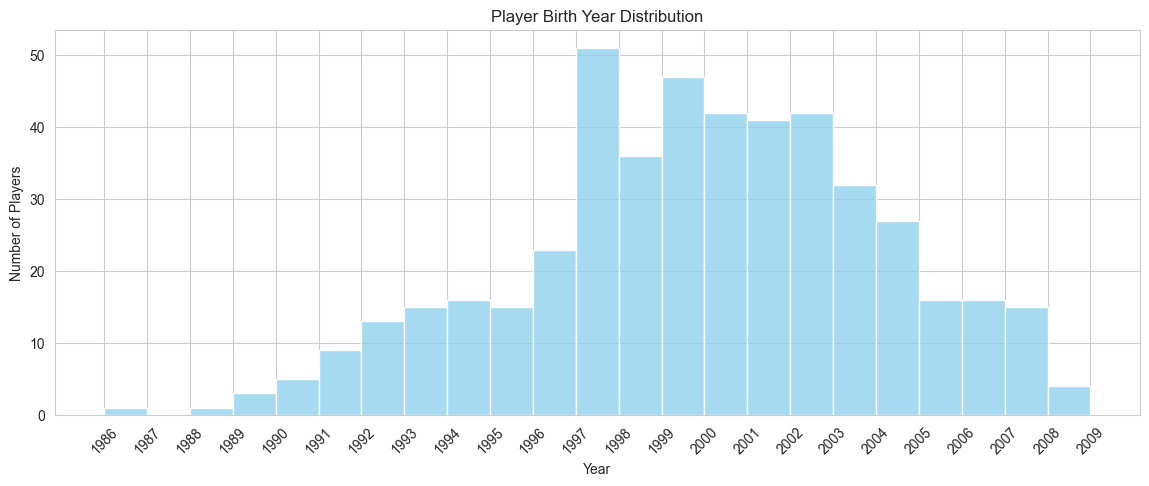

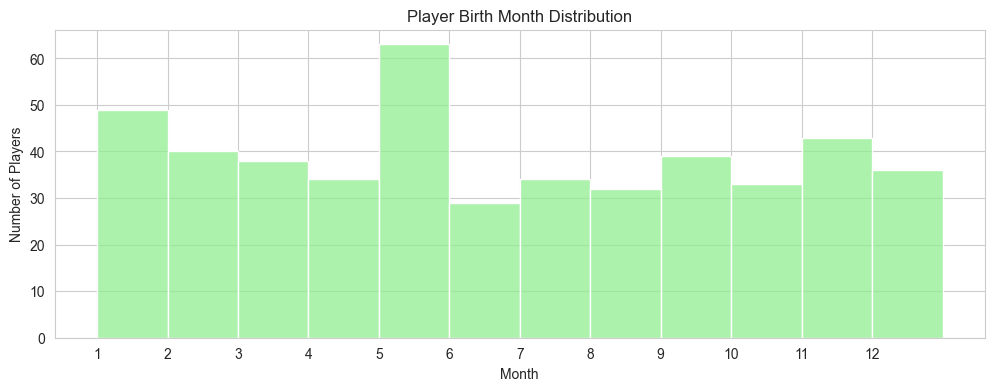

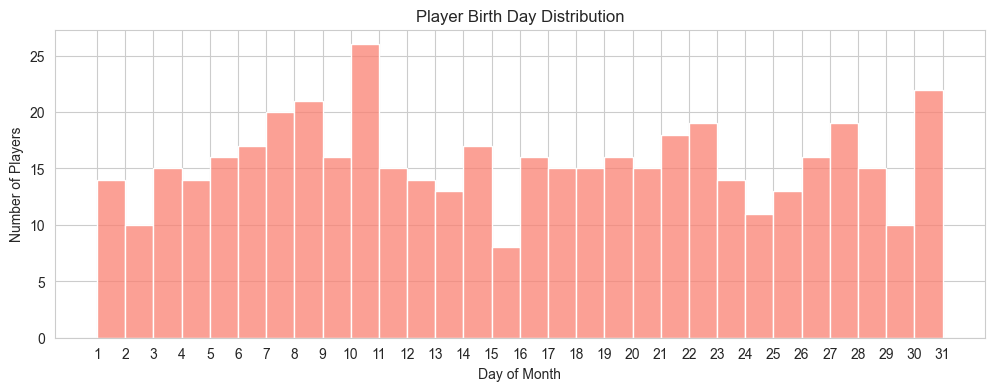

In [224]:
# Year histogram

df['birth_date'] = pd.to_datetime(df['birth_date'])

# Extract year, month, day
df['birth_year'] = df['birth_date'].dt.year
df['birth_month'] = df['birth_date'].dt.month
df['birth_day'] = df['birth_date'].dt.day


plt.figure(figsize=(14,5))
sns.histplot(df['birth_year'], bins=np.arange(df['birth_year'].min(), df['birth_year'].max()+1),
             kde=False, color='skyblue')
plt.title("Player Birth Year Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Players")
plt.xticks(np.arange(df['birth_year'].min(), df['birth_year'].max()+1), rotation=45)
plt.show()

# Month histogram
plt.figure(figsize=(12,4))
sns.histplot(df['birth_month'], bins=np.arange(1,14), kde=False, color='lightgreen')
plt.title("Player Birth Month Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Players")
plt.xticks(np.arange(1,13))
plt.show()

# Day histogram
plt.figure(figsize=(12,4))
sns.histplot(df['birth_day'], bins=np.arange(1,32), kde=False, color='salmon')
plt.title("Player Birth Day Distribution")
plt.xlabel("Day of Month")
plt.ylabel("Number of Players")
plt.xticks(np.arange(1,32))
plt.show()

In [225]:
# Describe year, month, day and combine nicely
summary = pd.concat([
    df['birth_year'].describe(),
    df['birth_month'].describe(),
    df['birth_day'].describe()
], axis=1)

summary.columns = ['Year', 'Month', 'Day']
summary

,Year,Month,Day
count,470.000000,470.000000,470.000000
mean,1999.382979,6.272340,15.502128
std,4.186246,3.511522,8.629732
min,1986.000000,1.000000,1.000000
25%,1997.000000,3.000000,8.000000
50%,1999.500000,6.000000,15.000000
75%,2002.000000,9.000000,23.000000
max,2009.000000,12.000000,31.000000


<Axes: ylabel='birth_year'>

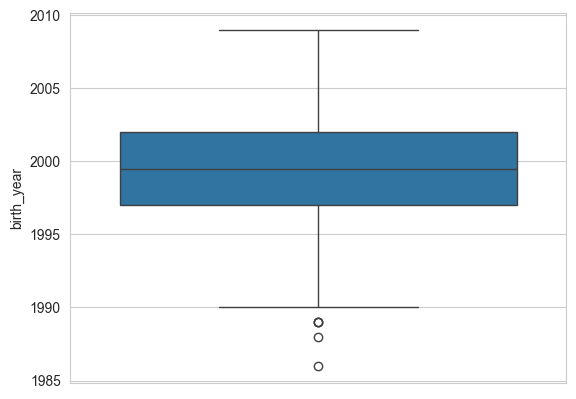

In [231]:
sns.boxplot(df['birth_year'])

<Axes: ylabel='birth_month'>

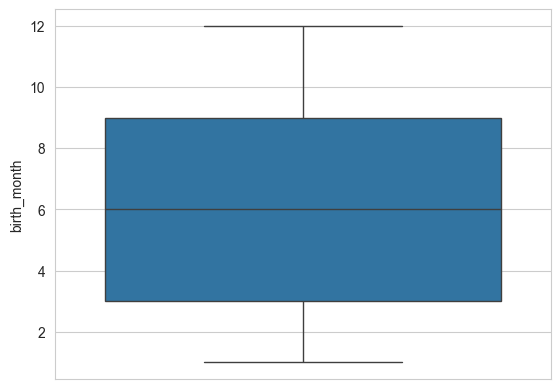

In [232]:
sns.boxplot(df['birth_month'])

<Axes: ylabel='birth_day'>

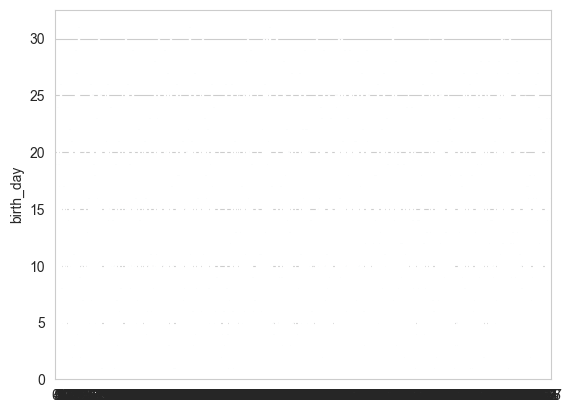